# Diagrame Capitolul 3 — Licență
Acest notebook generează toate figurile necesare pentru capitolul 3.
Rulează celulele în ordine. Figurile se salvează în `../figures/`.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
os.makedirs("../figures", exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from ml.preprocess import load_data, preprocess_movies_and_tags, build_popularity_scores
from ml.content_based import ContentBasedRecommender
from ml.collaborative import CollaborativeRecommender

PLT_STYLE = {
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans"
}
plt.rcParams.update(PLT_STYLE)

COLOR_PRIMARY   = "#534AB7"
COLOR_SECONDARY = "#1D9E75"
COLOR_ACCENT    = "#E8553E"
COLOR_NEUTRAL   = "#AAAAAA"

In [3]:
ratings, movies, tags, links = load_data(
    ratings_path="../data/ratings.csv",
    movies_path="../data/movies.csv",
    tags_path="../data/tags.csv",
    links_path="../data/links.csv"
)
movie_features = preprocess_movies_and_tags(movies, tags, links, include_title=True)
popularity_df  = build_popularity_scores(ratings, movie_features)
print("Date încărcate:", ratings.shape, movies.shape)

Date încărcate: (100836, 3) (9742, 3)


## 1. Calculul scorurilor de popularitate

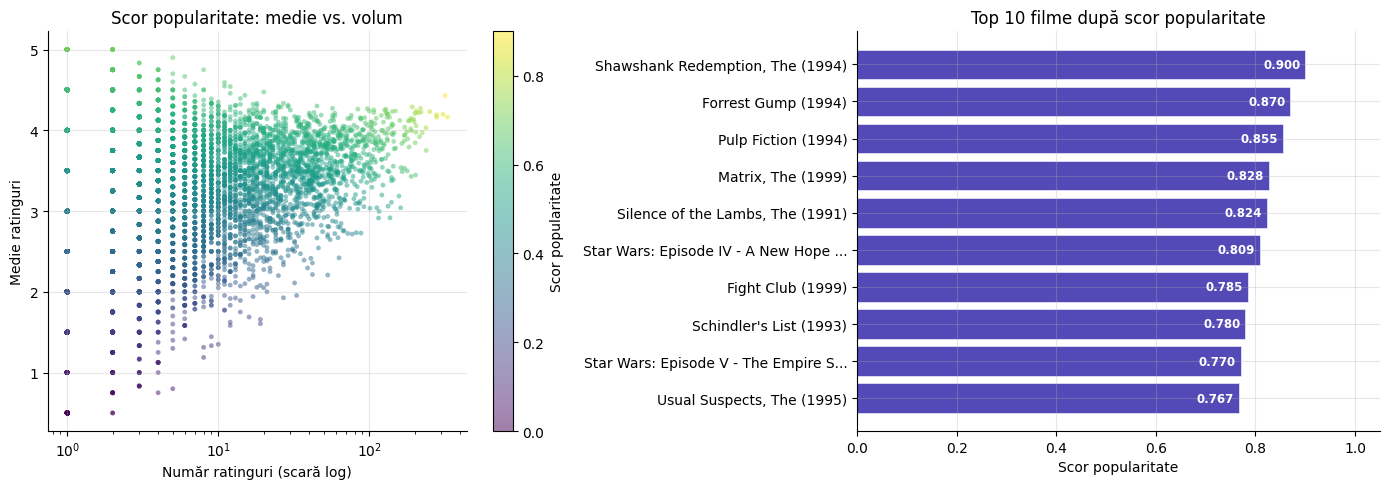

Salvat: cap3_1_popularitate.png


In [4]:
# --- Figura 1: Scatter avg_rating vs rating_count, colorat dupa popularity_score ---
df_pop = popularity_df[popularity_df["rating_count"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stânga: scatter avg_rating vs rating_count
sc = axes[0].scatter(
    df_pop["rating_count"],
    df_pop["avg_rating"],
    c=df_pop["popularity_score"],
    cmap="viridis",
    alpha=0.5,
    s=12,
    linewidths=0
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Număr ratinguri (scară log)")
axes[0].set_ylabel("Medie ratinguri")
axes[0].set_title("Scor popularitate: medie vs. volum", fontsize=12)
cbar = fig.colorbar(sc, ax=axes[0])
cbar.set_label("Scor popularitate")

# Dreapta: top 10 filme după scor final
top10 = popularity_df.sort_values("popularity_score", ascending=False).head(10)
titles_short = [t[:35] + "..." if len(t) > 35 else t for t in top10["title"]]
bars = axes[1].barh(titles_short[::-1], top10["popularity_score"].values[::-1],
                    color=COLOR_PRIMARY, edgecolor="white", linewidth=0.4)
for bar, val in zip(bars, top10["popularity_score"].values[::-1]):
    axes[1].text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", ha="right", fontsize=8.5, color="white", fontweight="bold")
axes[1].set_xlabel("Scor popularitate")
axes[1].set_title("Top 10 filme după scor popularitate", fontsize=12)
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig("../figures/cap3_1_popularitate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvat: cap3_1_popularitate.png")

## 2. Vectorizarea TF-IDF

In [5]:
# Antrenăm vectorizatorul
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(movie_features["content_text"].fillna(""))
feature_names = vectorizer.get_feature_names_out()
print(f"Matrice TF-IDF: {tfidf_matrix.shape[0]} filme × {tfidf_matrix.shape[1]} termeni")
print(f"Valori nenule: {tfidf_matrix.nnz:,} ({100*tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.2f}% din total)")

Matrice TF-IDF: 9742 filme × 5000 termeni
Valori nenule: 43,954 (0.09% din total)


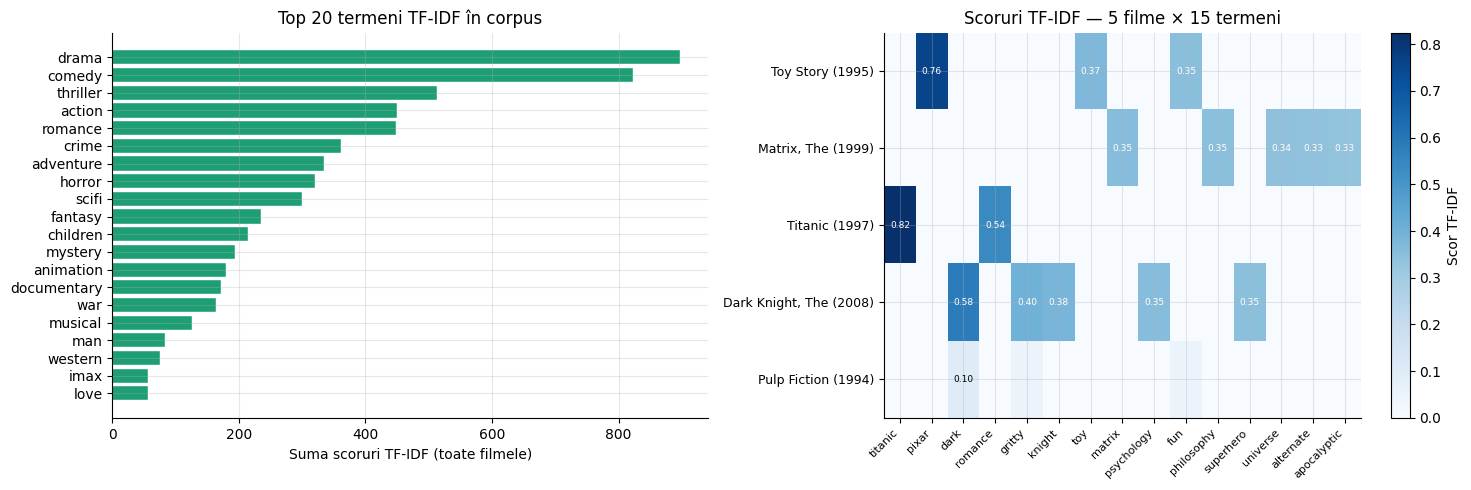

Salvat: cap3_2_tfidf.png


In [6]:
# --- Figura 2: Top termeni TF-IDF + heatmap pentru 5 filme exemple ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stânga: top 20 termeni după suma scorurilor
term_scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top20_idx   = term_scores.argsort()[::-1][:20]
axes[0].barh(feature_names[top20_idx][::-1], term_scores[top20_idx][::-1],
             color=COLOR_SECONDARY, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Suma scoruri TF-IDF (toate filmele)")
axes[0].set_title("Top 20 termeni TF-IDF în corpus", fontsize=12)

# Dreapta: heatmap TF-IDF pentru 5 filme reprezentative și top 15 termeni ai lor
sample_titles = [
    "Toy Story (1995)",
    "Matrix, The (1999)",
    "Titanic (1997)",
    "Dark Knight, The (2008)",
    "Pulp Fiction (1994)"
]
sample_rows   = []
valid_titles  = []
for title in sample_titles:
    row = movie_features[movie_features["title"] == title]
    if not row.empty:
        idx = row.index[0]
        loc = movie_features.index.get_loc(idx)
        sample_rows.append(loc)
        valid_titles.append(title[:25])

if sample_rows:
    sub_matrix = tfidf_matrix[sample_rows].toarray()
    top15_local = sub_matrix.max(axis=0).argsort()[::-1][:15]
    heatmap_data = sub_matrix[:, top15_local]
    im = axes[1].imshow(heatmap_data, aspect="auto", cmap="Blues")
    axes[1].set_xticks(range(15))
    axes[1].set_xticklabels(feature_names[top15_local], rotation=45, ha="right", fontsize=8)
    axes[1].set_yticks(range(len(valid_titles)))
    axes[1].set_yticklabels(valid_titles, fontsize=9)
    axes[1].set_title("Scoruri TF-IDF — 5 filme × 15 termeni", fontsize=12)
    plt.colorbar(im, ax=axes[1], label="Scor TF-IDF")
    for i in range(len(valid_titles)):
        for j in range(15):
            val = heatmap_data[i, j]
            if val > 0.05:
                axes[1].text(j, i, f"{val:.2f}", ha="center", va="center",
                             fontsize=6.5, color="white" if val > 0.2 else "black")

plt.tight_layout()
plt.savefig("../figures/cap3_2_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvat: cap3_2_tfidf.png")

## 2b. Embeddings semantice SBERT
Modelul `all-MiniLM-L6-v2` (384-dim) captează semantica textului dincolo de keyword overlap.
Blending: `content_score = 0.55 × TF-IDF + 0.45 × SBERT`.
Embeddings-urile se calculează o singură dată și sunt cache-uite în `data/sbert_cache_*.npy`.

In [ ]:
# Antrenare CB cu SBERT (prima rulare: ~5-15 min; ulterior: <1s din cache)
# use_sbert=True este default-ul sistemului în producție
cb_sbert = ContentBasedRecommender(max_features=5000, use_sbert=True)
cb_sbert.fit(movie_features)
has_sbert = cb_sbert.sbert_matrix is not None
print(f"TF-IDF: {cb_sbert.tfidf_matrix.shape}")
if has_sbert:
    print(f"SBERT:  {cb_sbert.sbert_matrix.shape}")
else:
    print("SBERT indisponibil — instalați: pip install sentence-transformers")

# Perechi de filme pentru comparație TF-IDF vs SBERT
film_pairs = [
    ("Toy Story (1995)",       "Shrek (2001)",            "animație/familie"),
    ("Toy Story (1995)",       "Toy Story 2 (1999)",      "continuare directă"),
    ("Matrix, The (1999)",     "Inception (2010)",        "sci-fi conceptual"),
    ("Matrix, The (1999)",     "Speed (1994)",            "acțiune pur"),
    ("Pulp Fiction (1994)",    "Reservoir Dogs (1992)",   "stil Tarantino"),
    ("Pulp Fiction (1994)",    "Forrest Gump (1994)",     "drama/comedie"),
    ("Dark Knight, The (2008)","Batman Begins (2005)",    "același univers"),
    ("Dark Knight, The (2008)","Joker (2019)",            "psihologie similară"),
]

results_pairs = []
for ref_title, comp_title, label in film_pairs:
    r1 = movie_features[movie_features["title"] == ref_title]
    r2 = movie_features[movie_features["title"] == comp_title]
    if r1.empty or r2.empty:
        continue
    i1 = cb_sbert.movie_id_to_idx.get(int(r1.iloc[0]["movieId"]))
    i2 = cb_sbert.movie_id_to_idx.get(int(r2.iloc[0]["movieId"]))
    if i1 is None or i2 is None:
        continue
    from sklearn.metrics.pairwise import linear_kernel as lk_
    tfidf_sim = float(lk_(cb_sbert.tfidf_matrix[i1], cb_sbert.tfidf_matrix[i2])[0][0])
    if has_sbert:
        import numpy as _np
        v1 = cb_sbert.sbert_matrix[i1].astype('float32')
        v2 = cb_sbert.sbert_matrix[i2].astype('float32')
        v1 /= (_np.linalg.norm(v1) + 1e-10)
        v2 /= (_np.linalg.norm(v2) + 1e-10)
        sbert_sim = float(_np.dot(v1, v2))
    else:
        sbert_sim = None
    results_pairs.append((f"{ref_title[:20]}…\nvs {comp_title[:20]}", label, tfidf_sim, sbert_sim))
    print(f"{label:25s}  TF-IDF={tfidf_sim:.3f}  SBERT={'N/A' if sbert_sim is None else f'{sbert_sim:.3f}'}")

# --- Figura 2b: TF-IDF vs SBERT similarity per pereche ---
if results_pairs:
    labels_plot = [r[0] for r in results_pairs]
    tfidf_vals  = [r[2] for r in results_pairs]
    sbert_vals  = [r[3] for r in results_pairs]

    x_  = np.arange(len(labels_plot))
    w_  = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    b1 = ax.bar(x_ - w_/2, tfidf_vals, w_, label="TF-IDF cosine",   color=COLOR_PRIMARY,   alpha=0.9, edgecolor='white')
    if any(v is not None for v in sbert_vals):
        sv = [v if v is not None else 0 for v in sbert_vals]
        b2 = ax.bar(x_ + w_/2, sv, w_, label="SBERT cosine", color=COLOR_SECONDARY, alpha=0.85, edgecolor='white')
    ax.set_xticks(x_)
    ax.set_xticklabels(labels_plot, fontsize=7.5)
    ax.set_ylabel("Similaritate cosinus")
    ax.set_title("Comparație TF-IDF vs SBERT — perechi de filme", fontsize=13)
    ax.set_ylim(0, 1.15)
    ax.legend()
    for bar, val in [(b, v) for b, v in zip(b1, tfidf_vals)]:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig("../figures/cap3_2b_sbert.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvat: cap3_2b_sbert.png")

## 3. Calculul similarității cosinus

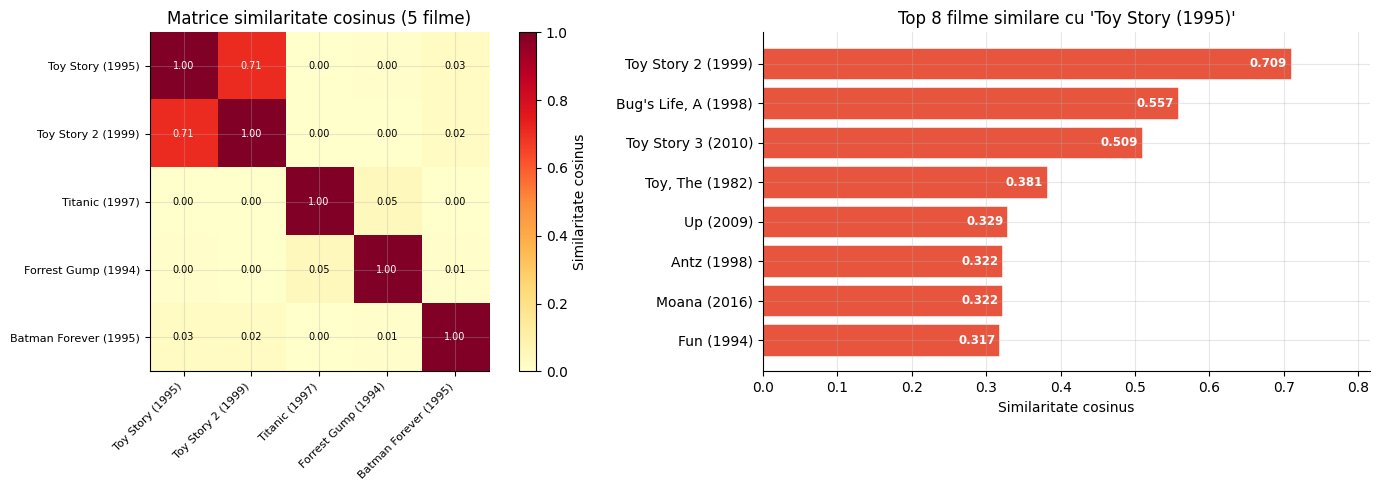

Salvat: cap3_3_cosine_similarity.png


In [7]:
# --- Figura 3: Heatmap similaritate cosinus pentru 8 filme ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Selectăm 8 filme reprezentative din genuri diferite
sim_titles = [
    "Toy Story (1995)", "Toy Story 2 (1999)",
    "The Matrix (1999)", "The Matrix Reloaded (2003)",
    "Titanic (1997)", "Forrest Gump (1994)",
    "The Dark Knight (2008)", "Batman Forever (1995)"
]
sel_rows, sel_labels = [], []
for title in sim_titles:
    row = movie_features[movie_features["title"] == title]
    if not row.empty:
        loc = movie_features.index.get_loc(row.index[0])
        sel_rows.append(loc)
        sel_labels.append(title[:22])

if sel_rows:
    vecs     = tfidf_matrix[sel_rows]
    sim_mat  = linear_kernel(vecs, vecs)
    n        = len(sel_labels)

    # Stânga: heatmap
    im = axes[0].imshow(sim_mat, vmin=0, vmax=1, cmap="YlOrRd")
    axes[0].set_xticks(range(n))
    axes[0].set_xticklabels(sel_labels, rotation=45, ha="right", fontsize=8)
    axes[0].set_yticks(range(n))
    axes[0].set_yticklabels(sel_labels, fontsize=8)
    axes[0].set_title(f"Matrice similaritate cosinus ({n} filme)", fontsize=12)
    plt.colorbar(im, ax=axes[0], label="Similaritate cosinus")
    for i in range(n):
        for j in range(n):
            axes[0].text(j, i, f"{sim_mat[i,j]:.2f}",
                         ha="center", va="center", fontsize=7,
                         color="white" if sim_mat[i,j] > 0.5 else "black")

# Dreapta: top 8 cele mai similare cu Toy Story (1995)
ts_idx_list = [i for i, t in enumerate(sim_titles) if "Toy Story (1995)" in t]
if ts_idx_list:
    ts_i    = ts_idx_list[0]
    all_sims = linear_kernel(tfidf_matrix[sel_rows[ts_i]], tfidf_matrix).flatten()
    top_idx  = all_sims.argsort()[::-1][1:9]
    top_titles = [movie_features.iloc[i]["title"][:30] for i in top_idx]
    top_sims   = all_sims[top_idx]
    bars = axes[1].barh(top_titles[::-1], top_sims[::-1],
                        color=COLOR_ACCENT, edgecolor="white", linewidth=0.4)
    for bar, val in zip(bars, top_sims[::-1]):
        axes[1].text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                     f"{val:.3f}", va="center", ha="right", fontsize=8.5,
                     color="white", fontweight="bold")
    axes[1].set_xlabel("Similaritate cosinus")
    axes[1].set_title("Top 8 filme similare cu 'Toy Story (1995)'", fontsize=12)
    axes[1].set_xlim(0, max(top_sims) * 1.15)

plt.tight_layout()
plt.savefig("../figures/cap3_3_cosine_similarity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvat: cap3_3_cosine_similarity.png")

## 4. Antrenarea modelului SVD

In [ ]:
# Antrenăm SVD cu noul API
svd_model = CollaborativeRecommender(random_state=42)
svd_model.load_ratings(ratings)
svd_model.build_user_matrix()
print(f"SVD antrenat: {svd_model.item_factors.shape[0]} filme × {svd_model.item_factors.shape[1]} factori latenti")

# Evaluare Precision@10 si NDCG@10: SVD vs Neighborhood CF (fallback)
eval_users_05 = ratings.groupby("userId").size()
eval_users_05 = eval_users_05[eval_users_05 >= 20].index.tolist()[:50]

def _prec_k(rec, rel, k=10):
    return sum(1 for m in rec[:k] if m in rel) / k

def _ndcg_k(rec, rel, k=10):
    dcg = sum(1/np.log2(i+2) for i, m in enumerate(rec[:k]) if m in rel)
    ideal = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
    return dcg/ideal if ideal > 0 else 0.0

res_svd_eval, res_nbhd_eval = [], []
for uid in eval_users_05:
    user_df = ratings[ratings["userId"] == uid]
    n = len(user_df)
    n_test = max(1, int(n * 0.2))
    train_df, test_df = user_df.iloc[:-n_test], user_df.iloc[-n_test:]
    rel = set(test_df[test_df["rating"] >= 4.0]["movieId"].astype(int))
    if not rel:
        continue
    urd = {int(r.movieId): float(r.rating) for r in train_df.itertuples()}
    if len(urd) < 3:
        continue
    svd_s = svd_model.get_cf_scores_for_ratings(urd)
    svd_top = sorted(svd_s, key=svd_s.get, reverse=True)[:10]
    orig = svd_model.item_factors
    svd_model.item_factors = None
    nbhd_s = svd_model.get_cf_scores_for_ratings(urd, top_k=150)
    svd_model.item_factors = orig
    nbhd_top = sorted(nbhd_s, key=nbhd_s.get, reverse=True)[:10] if nbhd_s else []
    res_svd_eval.append((_prec_k(svd_top, rel), _ndcg_k(svd_top, rel)))
    res_nbhd_eval.append((_prec_k(nbhd_top, rel), _ndcg_k(nbhd_top, rel)))

prec_svd_eval  = np.mean([r[0] for r in res_svd_eval])  if res_svd_eval  else 0
ndcg_svd_eval  = np.mean([r[1] for r in res_svd_eval])  if res_svd_eval  else 0
prec_nbhd_eval = np.mean([r[0] for r in res_nbhd_eval]) if res_nbhd_eval else 0
ndcg_nbhd_eval = np.mean([r[1] for r in res_nbhd_eval]) if res_nbhd_eval else 0
print(f"SVD:          Precision@10={prec_svd_eval:.4f}  NDCG@10={ndcg_svd_eval:.4f}")
print(f"Neighborhood: Precision@10={prec_nbhd_eval:.4f}  NDCG@10={ndcg_nbhd_eval:.4f}")

In [ ]:
# --- Figura 4: Comparatie Precision@10 + NDCG@10 + distributia scorurilor CF ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stânga: grouped bar Precision@10 si NDCG@10
models_names = ["SVD\n(Matrix\nFactorization)", "Neighborhood\n(Adjusted Cosine)"]
x = np.arange(len(models_names))
w = 0.35
prec_vals = [prec_svd_eval, prec_nbhd_eval]
ndcg_vals = [ndcg_svd_eval, ndcg_nbhd_eval]

b1 = axes[0].bar(x - w/2, prec_vals, w, color=COLOR_PRIMARY, alpha=0.9, label="Precision@10", edgecolor="white")
b2 = axes[0].bar(x + w/2, ndcg_vals, w, color=COLOR_SECONDARY, alpha=0.85, label="NDCG@10", edgecolor="white")
for bar, val in list(zip(b1, prec_vals)) + list(zip(b2, ndcg_vals)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names)
axes[0].set_ylabel("Metrica")
axes[0].set_title("Comparație Precision@10 și NDCG@10:\nSVD vs Neighborhood CF", fontsize=12)
axes[0].set_ylim(0, max(prec_vals + ndcg_vals) * 1.35)
axes[0].legend()

# Dreapta: distributia scorurilor SVD pentru user 4
user4_rats = {int(r.movieId): float(r.rating) for r in ratings[ratings["userId"] == 4].itertuples()}
cf_u4 = svd_model.get_cf_scores_for_ratings(user4_rats)
cf_vals_u4 = list(cf_u4.values())
axes[1].hist(cf_vals_u4, bins=40, color=COLOR_PRIMARY, edgecolor="white", linewidth=0.3, alpha=0.85)
mean_cf_u4 = np.mean(cf_vals_u4)
axes[1].axvline(mean_cf_u4, color=COLOR_ACCENT, linewidth=1.8, linestyle="--",
                label=f"Medie: {mean_cf_u4:.2f}")
axes[1].set_xlabel("Scor CF (SVD fold-in)")
axes[1].set_ylabel("Număr filme")
axes[1].set_title("Distribuția scorurilor CF (SVD, user=4)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/cap3_4_svd_antrenare.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvat: cap3_4_svd_antrenare.png")

## 5. Predicții batch

In [ ]:
# --- Figura 5: Batch prediction — top 10 scoruri CF pentru user 4 ---
import time

user4_all_rats = {int(r.movieId): float(r.rating) for r in ratings[ratings["userId"] == 4].itertuples()}

t0 = time.time()
all_cf_scores = svd_model.get_cf_scores_for_ratings(user4_all_rats)
t_batch = time.time() - t0
print(f"SVD fold-in: {len(all_cf_scores):,} filme în {t_batch*1000:.1f}ms")

batch_scores = pd.DataFrame(list(all_cf_scores.items()), columns=["movieId", "collaborative_score"])
top10_svd = batch_scores.sort_values("collaborative_score", ascending=False).head(10)
top10_svd = top10_svd.merge(movies[["movieId", "title"]], on="movieId")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titles_s = [t[:32] + "..." if len(t) > 32 else t for t in top10_svd["title"]]
top10_vals = top10_svd["collaborative_score"].values
axes[0].barh(titles_s[::-1], top10_vals[::-1], color=COLOR_PRIMARY, edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Scor CF (SVD fold-in)")
axes[0].set_title(
    f"Top 10 recomandări SVD — user 4\n({len(all_cf_scores):,} candidați în {t_batch*1000:.0f}ms)",
    fontsize=11
)

q95 = batch_scores["collaborative_score"].quantile(0.95)
axes[1].hist(batch_scores["collaborative_score"], bins=50,
             color=COLOR_PRIMARY, edgecolor="white", linewidth=0.2, alpha=0.85)
axes[1].axvline(q95, color=COLOR_ACCENT, linewidth=1.8, linestyle="--",
                label=f"Percentila 95: {q95:.2f}")
axes[1].set_xlabel("Scor CF (SVD)")
axes[1].set_ylabel("Număr filme candidat")
axes[1].set_title(f"Distribuția scorurilor batch ({len(all_cf_scores):,} filme)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/cap3_5_batch_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvat: cap3_5_batch_prediction.png")

In [11]:
# Găsim un user cu medie între 3.5-4.2 și minim 50 rating-uri
user_stats = ratings.groupby("userId")["rating"].agg(["mean", "count"])
user_stats = user_stats[(user_stats["mean"].between(3.5, 4.2)) & 
                        (user_stats["count"] >= 50)]
print(user_stats.head(10))

            mean  count
userId                 
4       3.555556    216
11      3.781250     64
16      3.724490     98
18      3.732072    502
20      3.590909    242
23      3.648760    121
24      3.650000    110
27      3.548148    135
29      4.141975     81
31      3.920000     50


In [ ]:
test_user = user_stats.index[0]
user_ratings_test = {
    int(r.movieId): float(r.rating)
    for r in ratings[ratings["userId"] == test_user].itertuples()
}
cf_test = svd_model.get_cf_scores_for_ratings(user_ratings_test)
test_scores = pd.DataFrame(list(cf_test.items()), columns=["movieId", "collaborative_score"])
print(test_scores["collaborative_score"].describe())

## 6. Logica adaptivă de combinare

In [ ]:
# --- Figura 6: Flowchart logica hibridă — versiune corectă cu POP ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

def draw_box(ax, x, y, text, color, text_color='white', fontsize=9.5, style='round,pad=0.15'):
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, color=text_color,
            bbox=dict(boxstyle=style, facecolor=color, edgecolor='white', linewidth=1.5),
            fontweight='bold', multialignment='center', zorder=3)

def arrow(ax, x1, y1, x2, y2, label='', color='#555555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        ax.text((x1+x2)/2 + 0.15, (y1+y2)/2, label, fontsize=8, color=color, va='center')

# Noduri principale
draw_box(ax, 5, 10.2, 'Utilizator face request', '#333333', fontsize=10)
draw_box(ax, 5,  8.8, 'len(signal) < 3?\n(filme cu rating ≥ 3.0)', '#534AB7', fontsize=9.5)

# Ramura DA (semnal insuficient)
draw_box(ax, 1.8, 7.2, '[ ]\nSemnal insuficient', COLOR_ACCENT, fontsize=9)

# Ramura NU
draw_box(ax, 7,   7.2, 'Calculare scoruri:\nCB (TF-IDF+SBERT)  |  POP', '#1a7a5e', fontsize=9)
draw_box(ax, 7,   5.8, 'CF overlap ≥ 10 filme\ncu scor SVD > 0?', '#534AB7', fontsize=9.5)

# Sub-ramuri CF activ / inactiv
draw_box(ax, 3.8, 4.3, 'Blend fallback:\n~73% CB + ~27% POP\n(w_cf ignorat)', '#E8973E', fontsize=8.5)
draw_box(ax, 9.2, 4.3, 'Blend complet:\n55% CB + 25% CF + 20% POP', COLOR_SECONDARY, fontsize=8.5)

# Convergenta
draw_box(ax, 6.5, 2.8, 'Normalizare min-max independentă\nper componentă [0, 1]', '#1a7a5e', fontsize=9)
draw_box(ax, 6.5, 1.6, 'final_score = w_cb·CB_norm + w_cf·CF_norm + w_pop·POP_norm', '#1a7a5e', fontsize=8.5)
draw_box(ax, 6.5, 0.5, 'Diversificare gen (max 3/gen) + Sampling ponderat → Top-N', '#222222', fontsize=9)

# Săgeți
arrow(ax, 5, 9.95, 5, 9.15)
arrow(ax, 5, 8.45, 1.8, 7.55, 'DA')
arrow(ax, 5, 8.45, 7,   7.55, 'NU')
arrow(ax, 7, 6.85, 7,   6.15)
arrow(ax, 7, 5.45, 3.8, 4.65, 'NU')
arrow(ax, 7, 5.45, 9.2, 4.65, 'DA')
arrow(ax, 3.8, 3.95, 6.5, 3.10)
arrow(ax, 9.2, 3.95, 6.5, 3.10)
arrow(ax, 6.5, 2.5,  6.5, 1.95)
arrow(ax, 6.5, 1.25, 6.5, 0.80)

ax.set_title('Logica adaptivă de combinare — Sistemul Hibrid',
             fontsize=13, fontweight='bold', pad=8, color='#222222')
plt.tight_layout()
plt.savefig('../figures/cap3_6_logica_adaptiva.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: cap3_6_logica_adaptiva.png')

## 4b. Optimizarea ponderilor hibride
Script-ul `ml/tune_weights.py` rulează un grid search pe MovieLens cu split cronologic (80/20 per user).
Metrica optimizată: **NDCG@10** (Normalized Discounted Cumulative Gain).
Rezultatul este salvat în `ml/best_weights.json`.

In [ ]:
import json, os

# Încărcăm ponderile tunat (dacă există) sau folosim default-ul
weights_path = '../ml/best_weights.json'
if os.path.exists(weights_path):
    with open(weights_path) as f_w:
        best_w = json.load(f_w)
    w_cb, w_cf, w_pop = best_w['cb'], best_w['cf'], best_w['pop']
    ndcg_val  = best_w.get('ndcg_at_10', best_w.get('ndcg_at_k', None))
    prec_val  = best_w.get('precision_at_10', best_w.get('precision_at_k', None))
    n_users   = best_w.get('n_users_evaluated', '?')
    print(f'Ponderi tunat (best_weights.json):')
    print(f'  CB={w_cb}  CF={w_cf}  POP={w_pop}')
    print(f'  NDCG@10={ndcg_val}  Precision@10={prec_val}  (evaluat pe {n_users} useri)')
else:
    w_cb, w_cf, w_pop = 0.55, 0.25, 0.20
    ndcg_val, prec_val, n_users = None, None, '—'
    print('best_weights.json lipsește — folosim ponderi default (0.55 / 0.25 / 0.20)')
    print('Rulați: python -m ml.tune_weights  (din rădăcina proiectului)')

# --- Figura 4b: Distribuția ponderilor optime ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stânga: pie chart al ponderilor
components = ['Content-Based\n(TF-IDF + SBERT)', 'Collaborative\nFiltering (SVD)', 'Popularity\n(Bayesian)']
weights_val = [w_cb, w_cf, w_pop]
colors_pie  = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT]
explode     = (0.04, 0.04, 0.04)
wedges, texts, autotexts = axes[0].pie(
    weights_val, labels=components, colors=colors_pie, explode=explode,
    autopct='%1.0f%%', startangle=90, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(11)
axes[0].set_title('Ponderi optime hibride', fontsize=12)

# Dreapta: comparatie grila ponderi — Precision@10 vs NDCG@10 (din evaluarea noastra)
metric_names = ['Precision@10\n(SVD)', 'NDCG@10\n(SVD)', 'Precision@10\n(Neighborhood)', 'NDCG@10\n(Neighborhood)']
metric_vals  = [prec_svd_eval, ndcg_svd_eval, prec_nbhd_eval, ndcg_nbhd_eval]
bar_colors   = [COLOR_PRIMARY, COLOR_PRIMARY, COLOR_SECONDARY, COLOR_SECONDARY]
bar_alpha    = [0.95, 0.6, 0.95, 0.6]
bars_ = axes[1].bar(metric_names, metric_vals, color=bar_colors,
                    alpha=0.85, edgecolor='white', width=0.55)
for bar_, val_ in zip(bars_, metric_vals):
    axes[1].text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.002,
                 f'{val_:.4f}', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_ylabel('Metrica')
axes[1].set_title('Metrici offline: SVD vs Neighborhood CF\n(evaluare pe 50 useri, split 80/20)', fontsize=11)
axes[1].set_ylim(0, max(metric_vals) * 1.3 if max(metric_vals) > 0 else 0.1)

plt.tight_layout()
plt.savefig('../figures/cap3_4b_tune_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: cap3_4b_tune_weights.png')

## 7. Normalizarea și calculul scorului final

In [ ]:
# Obținem scoruri reale pentru un utilizator activ (CF + CB + POP)
from sklearn.metrics.pairwise import linear_kernel as _lk

cb_model_norm = ContentBasedRecommender(max_features=5000, use_sbert=False)
cb_model_norm.fit(movie_features)

USER_ID = 1
user_ratings_uid = {
    int(r.movieId): float(r.rating)
    for r in ratings[ratings['userId'] == USER_ID].itertuples()
}

# CF scores (SVD)
cf_scores_uid = svd_model.get_cf_scores_for_ratings(user_ratings_uid)
df_cf = pd.DataFrame(list(cf_scores_uid.items()), columns=['movieId', 'collaborative_score']).head(500)

# CB scores
liked_ids_uid = [mid for mid, r in user_ratings_uid.items() if r >= 3.0 and mid in cb_model_norm.movie_id_to_idx]
candidate_ids_uid = [mid for mid in df_cf['movieId'].tolist() if mid in cb_model_norm.movie_id_to_idx]
if liked_ids_uid and candidate_ids_uid:
    liked_vecs_ = cb_model_norm.tfidf_matrix[[cb_model_norm.movie_id_to_idx[m] for m in liked_ids_uid]]
    cand_vecs_  = cb_model_norm.tfidf_matrix[[cb_model_norm.movie_id_to_idx[m] for m in candidate_ids_uid]]
    cbf_sim_uid = _lk(cand_vecs_, liked_vecs_).mean(axis=1)
else:
    cbf_sim_uid = np.zeros(len(candidate_ids_uid))
df_cbf = pd.DataFrame({'movieId': candidate_ids_uid, 'content_score': cbf_sim_uid.tolist()})

# POP scores
pop_map_uid = popularity_df.set_index('movieId')['popularity_score'].to_dict()
df_pop_scores = pd.DataFrame({'movieId': candidate_ids_uid,
                               'pop_score': [pop_map_uid.get(mid, 0.0) for mid in candidate_ids_uid]})

# Merge
df_merged = (df_cf[df_cf['movieId'].isin(candidate_ids_uid)]
             .merge(df_cbf, on='movieId')
             .merge(df_pop_scores, on='movieId'))

def min_max(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s * 0

df_merged['cf_norm']  = min_max(df_merged['collaborative_score'])
df_merged['cbf_norm'] = min_max(df_merged['content_score'])
df_merged['pop_norm'] = min_max(df_merged['pop_score'])
# Ponderi reale ale sistemului (din tune_weights)
df_merged['final_score'] = w_cb * df_merged['cbf_norm'] + w_cf * df_merged['cf_norm'] + w_pop * df_merged['pop_norm']

print(f'Filme analizate: {len(df_merged)}')
print(f'Ponderi folosite: CB={w_cb}  CF={w_cf}  POP={w_pop}')
print(df_merged[['collaborative_score', 'cf_norm', 'content_score', 'cbf_norm', 'pop_norm', 'final_score']].describe().round(4))

In [ ]:
# --- Figura 7: Before/after normalizare + scor final (3 componente) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stânga: scoruri brute CB vs CF
axes[0].scatter(df_merged['collaborative_score'], df_merged['content_score'],
                alpha=0.35, s=12, color=COLOR_NEUTRAL)
axes[0].set_xlabel('CF score (brut)')
axes[0].set_ylabel('CB score (brut)')
axes[0].set_title('Scoruri brute\n(scale diferite)', fontsize=11)
axes[0].annotate('Scale\ndiferite!', xy=(0.65, 0.85), xycoords='axes fraction',
                 fontsize=9, color=COLOR_ACCENT, fontweight='bold')

# Mijloc: scoruri normalizate colorate după final_score
sc2 = axes[1].scatter(df_merged['cf_norm'], df_merged['cbf_norm'],
                       c=df_merged['final_score'], cmap='viridis', alpha=0.45, s=12)
plt.colorbar(sc2, ax=axes[1], label='final_score')
axes[1].set_xlabel('CF score (normalizat [0,1])')
axes[1].set_ylabel('CB score (normalizat [0,1])')
axes[1].set_title('Scoruri normalizate\n(aceeași scală)', fontsize=11)
axes[1].plot([0,1],[0,1], '--', color='gray', linewidth=1, alpha=0.5)

# Dreapta: top 10 cu 3 componente CB / CF / POP + final
top10_final = df_merged.sort_values('final_score', ascending=False).head(10)
top10_final = top10_final.merge(movies[['movieId','title']], on='movieId')
titles_f = [t[:26]+'...' if len(t)>26 else t for t in top10_final['title']]
x_ = np.arange(len(titles_f))
w_ = 0.20

axes[2].barh(x_ + 1.5*w_, top10_final['cf_norm'].values[::-1],  w_, label=f'CF  ({int(w_cf*100)}%)',  color=COLOR_SECONDARY, alpha=0.85)
axes[2].barh(x_ + 0.5*w_, top10_final['cbf_norm'].values[::-1], w_, label=f'CB  ({int(w_cb*100)}%)',  color=COLOR_PRIMARY,   alpha=0.85)
axes[2].barh(x_ - 0.5*w_, top10_final['pop_norm'].values[::-1], w_, label=f'POP ({int(w_pop*100)}%)', color=COLOR_ACCENT,    alpha=0.85)
axes[2].barh(x_ - 1.5*w_, top10_final['final_score'].values[::-1], w_, label='Final', color='#333333', alpha=0.9)
axes[2].set_yticks(x_)
axes[2].set_yticklabels(titles_f[::-1], fontsize=7.5)
axes[2].set_xlabel('Scor normalizat')
axes[2].set_title(f'Top 10 — componente vs. scor final\n(CB={w_cb}, CF={w_cf}, POP={w_pop})', fontsize=10)
axes[2].legend(fontsize=8, loc='lower right')
axes[2].set_xlim(0, 1.2)

plt.tight_layout()
plt.savefig('../figures/cap3_7_normalizare_scor_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: cap3_7_normalizare_scor_final.png')

---
## Rezumat figuri generate

| Fișier | Secțiune |
|--------|----------|
| `cap3_1_popularitate.png`         | 3.1.2 Calculul scorurilor de popularitate |
| `cap3_2_tfidf.png`                | 3.2.1 Vectorizarea TF-IDF |
| `cap3_2b_sbert.png`               | 3.2.2 Embeddings semantice SBERT |
| `cap3_3_cosine_similarity.png`    | 3.2.3 Calculul similarității cosinus |
| `cap3_4_svd_antrenare.png`        | 3.3.1 Antrenarea SVD — Precision@10 / NDCG@10 |
| `cap3_4b_tune_weights.png`        | 3.3.2 Optimizarea ponderilor hibride |
| `cap3_5_batch_prediction.png`     | 3.3.3 Predicții batch SVD |
| `cap3_6_logica_adaptiva.png`      | 3.4.1 Logica adaptivă de combinare |
| `cap3_7_normalizare_scor_final.png` | 3.4.2 Normalizarea și calculul scorului final |